# Preparação dos dados — Telco Customer Churn

Este notebook implementa o carregamento e o tratamento solicitados em `enunciado.ipynb`. O CSV é localizado por caminhos relativos à raiz do repositório, sem caminhos absolutos específicos da máquina.

O fluxo preserva o conjunto de teste: a limpeza determinística ocorre antes da divisão, mas imputação, escala e one-hot encoding são ajustados **somente nos dados de treino**.

## 1. Imports e configurações

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TARGET = "Churn"

## 2. Carregamento por caminho relativo

O texto do enunciado menciona `data/Telco-Customer-Churn.csv`, mas o arquivo deste repositório está na raiz e a própria célula de exemplo usa `Telco-Customer-Churn.csv`. A função abaixo aceita as duas disposições e procura a raiz a partir do diretório de trabalho atual.

In [ ]:
def localizar_arquivo_dados(nome_arquivo="Telco-Customer-Churn.csv"):
    diretorio_atual = Path.cwd()
    bases = (diretorio_atual, *diretorio_atual.parents)
    caminhos_relativos = (Path(nome_arquivo), Path("data") / nome_arquivo)

    for base in bases:
        # Evita escolher, por engano, um arquivo homônimo fora deste projeto.
        if not (base / "enunciado.ipynb").is_file():
            continue
        for caminho_relativo in caminhos_relativos:
            candidato = base / caminho_relativo
            if candidato.is_file():
                return candidato

    tentativas = ", ".join(str(item) for item in caminhos_relativos)
    raise FileNotFoundError(
        f"Não foi possível localizar o CSV. Caminhos relativos testados: {tentativas}. "
        "Execute o notebook dentro deste repositório."
    )


DATA_PATH = localizar_arquivo_dados()
df_raw = pd.read_csv(DATA_PATH)

print(f"Arquivo carregado: {DATA_PATH.relative_to(DATA_PATH.parent)}")
print(f"Dimensão original: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
display(df_raw.head())

## 3. Validação inicial e distribuição do alvo

A validação falha de forma explícita caso outro arquivo seja carregado por engano. A acurácia da classe majoritária também é calculada, pois ela define o baseline que qualquer modelo precisa superar.

In [ ]:
COLUNAS_ESPERADAS = [
    "customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
    "tenure", "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
    "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn",
]

colunas_ausentes = sorted(set(COLUNAS_ESPERADAS) - set(df_raw.columns))
colunas_extras = sorted(set(df_raw.columns) - set(COLUNAS_ESPERADAS))
if colunas_ausentes or colunas_extras:
    raise ValueError(
        f"Schema inesperado. Ausentes: {colunas_ausentes}; extras: {colunas_extras}"
    )
if not df_raw["customerID"].is_unique:
    raise ValueError("customerID deveria identificar unicamente cada cliente.")

df_raw.info()

distribuicao_churn = (
    df_raw[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .to_frame("quantidade")
)
distribuicao_churn["proporcao"] = (
    distribuicao_churn["quantidade"] / len(df_raw)
)
baseline_majoritario = distribuicao_churn["proporcao"].max()

display(distribuicao_churn.style.format({"proporcao": "{:.2%}"}))
print(f"Baseline que sempre prevê a classe majoritária: {baseline_majoritario:.2%}")

## 4. Investigação de `TotalCharges`

A conversão usa `errors='coerce'` apenas para diagnosticar os valores inválidos. Antes de preencher qualquer valor, verificamos se eles pertencem a clientes com `tenure == 0`, isto é, clientes novos que ainda não receberam cobrança.

In [ ]:
total_charges_numerico = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
mascara_total_invalido = total_charges_numerico.isna()
linhas_total_invalido = df_raw.loc[
    mascara_total_invalido,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"],
].copy()
linhas_total_invalido["valor_original_repr"] = (
    linhas_total_invalido["TotalCharges"].map(repr)
)

print(f"Valores não numéricos em TotalCharges: {mascara_total_invalido.sum()}")
display(linhas_total_invalido)

if not linhas_total_invalido["tenure"].eq(0).all():
    raise ValueError(
        "Há TotalCharges inválido para cliente com tenure diferente de zero; "
        "a regra de preenchimento precisa ser revista."
    )

## 5. Limpeza determinística

Decisões aplicadas:

- converter `TotalCharges` para número e preencher com `0` somente os registros de `tenure == 0`;
- mapear `Churn` para `No = 0` e `Yes = 1`;
- consolidar `No internet service` e `No phone service` em `No`, evitando categorias redundantes no one-hot encoding;
- preservar todas as linhas e validar as invariantes após a limpeza.

In [ ]:
COLUNAS_SERVICOS_INTERNET = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
MAPA_CHURN = {"No": 0, "Yes": 1}


def limpar_dados(dados):
    resultado = dados.copy()

    resultado["TotalCharges"] = pd.to_numeric(
        resultado["TotalCharges"], errors="coerce"
    )
    total_ausente = resultado["TotalCharges"].isna()
    ausente_com_tenure = total_ausente & resultado["tenure"].ne(0)
    if ausente_com_tenure.any():
        ids_problematicos = resultado.loc[ausente_com_tenure, "customerID"].tolist()
        raise ValueError(
            "TotalCharges ausente sem a justificativa tenure == 0. "
            f"Clientes: {ids_problematicos}"
        )
    resultado.loc[total_ausente, "TotalCharges"] = 0.0

    resultado[COLUNAS_SERVICOS_INTERNET] = resultado[
        COLUNAS_SERVICOS_INTERNET
    ].replace("No internet service", "No")
    resultado["MultipleLines"] = resultado["MultipleLines"].replace(
        "No phone service", "No"
    )

    resultado[TARGET] = resultado[TARGET].map(MAPA_CHURN)
    if resultado[TARGET].isna().any():
        raise ValueError("A coluna Churn contém valores diferentes de 'Yes' e 'No'.")

    return resultado


df = limpar_dados(df_raw)

In [ ]:
verificacoes = pd.Series(
    {
        "mesma quantidade de linhas": len(df) == len(df_raw),
        "TotalCharges numérico": pd.api.types.is_numeric_dtype(df["TotalCharges"]),
        "TotalCharges sem ausentes": df["TotalCharges"].notna().all(),
        "tenure zero implica TotalCharges zero": df.loc[
            df["tenure"].eq(0), "TotalCharges"
        ].eq(0).all(),
        "alvo binário": set(df[TARGET].unique()) == {0, 1},
        "sem categoria redundante de internet": not df[
            COLUNAS_SERVICOS_INTERNET
        ].eq("No internet service").any().any(),
        "sem categoria redundante de telefone": not df["MultipleLines"].eq(
            "No phone service"
        ).any(),
    },
    name="resultado",
)

if not verificacoes.all():
    raise AssertionError(
        f"Falha nas validações: {verificacoes.index[~verificacoes].tolist()}"
    )

display(verificacoes.to_frame())
display(df.head())

## 6. Features, alvo e divisão treino/teste

`customerID` é um identificador único e não deve ser usado como feature. `gender` e `PhoneService` também são removidas conforme a EDA já documentada no repositório (`p = 0,487` e `p = 0,339`, respectivamente). `TotalCharges` permanece disponível; para modelos lineares, sua remoção pode ser testada dentro da comparação de modelos por ser quase determinada por `tenure × MonthlyCharges`.

In [ ]:
COLUNAS_DESCARTADAS = ["customerID", "gender", "PhoneService"]

X = df.drop(columns=[TARGET, *COLUNAS_DESCARTADAS])
y = df[TARGET].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

colunas_numericas = X.select_dtypes(include="number").columns.tolist()
colunas_categoricas = X.select_dtypes(exclude="number").columns.tolist()

resumo_split = pd.DataFrame(
    {
        "linhas": [len(X_train), len(X_test)],
        "proporção de churn": [y_train.mean(), y_test.mean()],
    },
    index=["treino", "teste"],
)

print(f"Features numéricas ({len(colunas_numericas)}): {colunas_numericas}")
print(f"Features categóricas ({len(colunas_categoricas)}): {colunas_categoricas}")
display(resumo_split.style.format({"proporção de churn": "{:.2%}"}))

## 7. Imputação, escala e encoding sem vazamento

O preprocessador é reutilizável e deve ser colocado dentro do `Pipeline` de cada modelo. A cópia usada para validação abaixo é ajustada somente em `X_train`; `X_test` é apenas transformado.

In [ ]:
def criar_one_hot_encoder():
    parametros = {"handle_unknown": "ignore", "drop": "first"}
    try:
        return OneHotEncoder(sparse_output=False, **parametros)
    except TypeError:
        # Compatibilidade com versões do scikit-learn anteriores à 1.2.
        return OneHotEncoder(sparse=False, **parametros)


def criar_preprocessador(numericas, categoricas):
    pipeline_numerico = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    pipeline_categorico = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", criar_one_hot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numericas", pipeline_numerico, numericas),
            ("categoricas", pipeline_categorico, categoricas),
        ],
        remainder="drop",
    )


preprocessador = criar_preprocessador(colunas_numericas, colunas_categoricas)

In [ ]:
# Esta cópia serve para validar o tratamento. Nos modelos, crie um novo
# preprocessador dentro de cada Pipeline para manter o isolamento.
preprocessador_validacao = clone(preprocessador)
X_train_tratado = preprocessador_validacao.fit_transform(X_train)
X_test_tratado = preprocessador_validacao.transform(X_test)
nomes_features_tratadas = preprocessador_validacao.get_feature_names_out()

if not np.isfinite(X_train_tratado).all() or not np.isfinite(X_test_tratado).all():
    raise AssertionError("O preprocessamento gerou NaN ou infinito.")
if X_train_tratado.shape[1] != X_test_tratado.shape[1]:
    raise AssertionError("Treino e teste ficaram com números diferentes de features.")

print(f"Treino antes/depois: {X_train.shape} -> {X_train_tratado.shape}")
print(f"Teste antes/depois:  {X_test.shape} -> {X_test_tratado.shape}")
print(f"Total de features após encoding: {len(nomes_features_tratadas)}")
display(pd.Series(nomes_features_tratadas, name="feature").to_frame().head(30))

## Resultado da preparação

Ao final deste notebook ficam disponíveis:

- `df_raw`: dados originais;
- `df`: dados limpos, com `TotalCharges` numérico e `Churn` binário;
- `X_train`, `X_test`, `y_train`, `y_test`: divisão estratificada;
- `preprocessador`: transformação ainda não ajustada, pronta para entrar no `Pipeline` de cada modelo;
- `X_train_tratado` e `X_test_tratado`: matrizes geradas para validar o tratamento.

A etapa de modelagem começa abaixo com a Regressão Logística. O enunciado ainda exige um segundo modelo para a comparação final.

## 8. Modelo 1 — Regressão Logística

A Regressão Logística é adequada como primeiro modelo porque produz a probabilidade de `Churn = 1`, aplica a função sigmoide e permite interpretar os coeficientes em termos de razão de chances (*odds ratio*).

Como o alvo é binário e desbalanceado, as métricas do módulo serão adaptadas para considerar explicitamente `Churn = 1` como classe positiva.

In [10]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

### Preparação específica do modelo

Para este modelo linear, `TotalCharges` é removida porque 99,91% de sua variação é explicada por `tenure × MonthlyCharges`; mantê-la tornaria os coeficientes menos estáveis. Um novo preprocessador é criado dentro do `Pipeline`, garantindo que imputação, escala e encoding sejam aprendidos apenas no treino.

`class_weight='balanced'` compensa a proporção de 73,46% `No` e 26,54% `Yes`, dando mais importância aos churners durante o ajuste.

In [11]:
X_train_logistica = X_train.drop(columns=["TotalCharges"])
X_test_logistica = X_test.drop(columns=["TotalCharges"])

numericas_logistica = X_train_logistica.select_dtypes(include="number").columns.tolist()
categoricas_logistica = X_train_logistica.select_dtypes(exclude="number").columns.tolist()

pipeline_logistica = Pipeline(
    steps=[
        (
            "preprocessamento",
            criar_preprocessador(numericas_logistica, categoricas_logistica),
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

pipeline_logistica.fit(X_train_logistica, y_train)
probabilidade_churn_logistica = pipeline_logistica.predict_proba(
    X_test_logistica
)[:, 1]
LIMIAR_PADRAO = 0.50
predicao_logistica = (probabilidade_churn_logistica >= LIMIAR_PADRAO).astype(int)

print(f"Modelo treinado com {len(X_train_logistica):,} clientes.")
print(f"Limiar de decisão aplicado: {LIMIAR_PADRAO:.2f}")

Modelo treinado com 5,634 clientes.
Limiar de decisão aplicado: 0.50


### Métricas de classificação

As métricas do módulo respondem a perguntas diferentes:

- **Acurácia:** proporção total de acertos; deve ser comparada ao baseline de 73,46%.
- **Precisão:** entre os clientes previstos como churn, quantos realmente cancelaram.
- **Recall:** entre os churners reais, quantos foram encontrados pelo modelo.
- **F1:** média harmônica entre precisão e recall da classe positiva.
- **ROC-AUC:** capacidade de ordenar churners acima de não churners, independentemente de um único limiar.

No exemplo multiclasse do módulo foi usado `average='weighted'`. Aqui usamos diretamente a classe positiva `1`, pois o problema é binário e o desempenho sobre churn é o que interessa ao negócio.

In [12]:
metricas_logistica = pd.DataFrame(
    {
        "métrica": [
            "Acurácia",
            "Precisão (Churn = 1)",
            "Recall (Churn = 1)",
            "F1 (Churn = 1)",
            "ROC-AUC",
        ],
        "valor": [
            accuracy_score(y_test, predicao_logistica),
            precision_score(y_test, predicao_logistica, pos_label=1, zero_division=0),
            recall_score(y_test, predicao_logistica, pos_label=1, zero_division=0),
            f1_score(y_test, predicao_logistica, pos_label=1, zero_division=0),
            roc_auc_score(y_test, probabilidade_churn_logistica),
        ],
    }
).set_index("métrica")

display(metricas_logistica.style.format({"valor": "{:.3f}"}))
print(
    f"Acurácia do baseline majoritário: {baseline_majoritario:.3f} | "
    f"acurácia da logística: {metricas_logistica.loc['Acurácia', 'valor']:.3f}"
)

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        predicao_logistica,
        labels=[0, 1],
        target_names=["No (permaneceu)", "Yes (churn)"],
        digits=3,
        zero_division=0,
    )
)

matriz_confusao_logistica = confusion_matrix(
    y_test, predicao_logistica, labels=[0, 1]
)
display(
    pd.DataFrame(
        matriz_confusao_logistica,
        index=["Real: No", "Real: Yes"],
        columns=["Previsto: No", "Previsto: Yes"],
    )
)

,valor
métrica,
Acurácia,0.743
Precisão (Churn = 1),0.511
Recall (Churn = 1),0.778
F1 (Churn = 1),0.617
ROC-AUC,0.839


Acurácia do baseline majoritário: 0.735 | acurácia da logística: 0.743

Relatório de classificação:
                 precision    recall  f1-score   support

No (permaneceu)      0.901     0.730     0.807      1035
    Yes (churn)      0.511     0.778     0.617       374

       accuracy                          0.743      1409
      macro avg      0.706     0.754     0.712      1409
   weighted avg      0.797     0.743     0.756      1409



,Previsto: No,Previsto: Yes
Real: No,756,279
Real: Yes,83,291


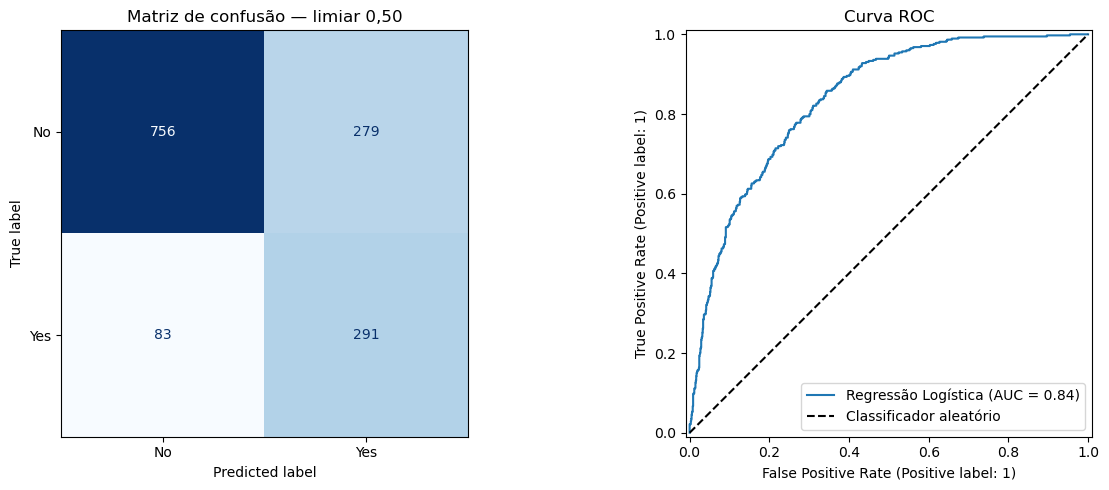

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_logistica,
    display_labels=["No", "Yes"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusão — limiar 0,50")

RocCurveDisplay.from_predictions(
    y_test,
    probabilidade_churn_logistica,
    name="Regressão Logística",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", label="Classificador aleatório")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Trade-off entre precisão e recall

Como mostrado no módulo de Regressão Logística, reduzir o limiar tende a encontrar mais churners (maior recall), mas gera mais falsos positivos (menor precisão). Os limiares abaixo são uma análise didática predefinida; não escolhemos o melhor limiar olhando o teste. Uma escolha operacional deve ser feita em validação ou validação cruzada, conforme o custo de `FP` e `FN`.

In [14]:
linhas_limiares = []
for limiar in [0.30, 0.50, 0.70]:
    predicao_limiar = (probabilidade_churn_logistica >= limiar).astype(int)
    linhas_limiares.append(
        {
            "limiar": limiar,
            "acurácia": accuracy_score(y_test, predicao_limiar),
            "precisão": precision_score(
                y_test, predicao_limiar, pos_label=1, zero_division=0
            ),
            "recall": recall_score(
                y_test, predicao_limiar, pos_label=1, zero_division=0
            ),
            "F1": f1_score(
                y_test, predicao_limiar, pos_label=1, zero_division=0
            ),
            "previstos como churn": int(predicao_limiar.sum()),
        }
    )

comparacao_limiares = pd.DataFrame(linhas_limiares).set_index("limiar")
display(
    comparacao_limiares.style.format(
        {"acurácia": "{:.3f}", "precisão": "{:.3f}", "recall": "{:.3f}", "F1": "{:.3f}"}
    )
)

,acurácia,precisão,recall,F1,previstos como churn
limiar,,,,,
0.300000,0.656,0.431,0.930,0.589,807
0.500000,0.743,0.511,0.778,0.617,570
0.700000,0.790,0.607,0.594,0.600,366


### Coeficientes e *odds ratios*

Coeficientes positivos aumentam as chances estimadas de churn; negativos reduzem. Como as variáveis numéricas foram padronizadas, seu *odds ratio* representa o efeito de aumentar um desvio-padrão. Para dummies, ele compara a categoria com a categoria de referência removida pelo encoder. Os valores são associativos, não causais.

In [15]:
preprocessamento_ajustado = pipeline_logistica.named_steps["preprocessamento"]
modelo_logistico_ajustado = pipeline_logistica.named_steps["modelo"]
nomes_logistica = preprocessamento_ajustado.get_feature_names_out()

coeficientes_logistica = pd.DataFrame(
    {
        "feature": nomes_logistica,
        "coeficiente": modelo_logistico_ajustado.coef_[0],
    }
)
coeficientes_logistica["feature"] = coeficientes_logistica["feature"].str.replace(
    r"^(numericas|categoricas)__", "", regex=True
)
coeficientes_logistica["odds_ratio"] = np.exp(
    coeficientes_logistica["coeficiente"]
)

mais_protetoras = coeficientes_logistica.nsmallest(7, "coeficiente").assign(
    direção="reduz chance estimada"
)
maior_risco = coeficientes_logistica.nlargest(7, "coeficiente").assign(
    direção="aumenta chance estimada"
)
principais_coeficientes = pd.concat([maior_risco, mais_protetoras], ignore_index=True)

display(
    principais_coeficientes.style.format(
        {"coeficiente": "{:.3f}", "odds_ratio": "{:.3f}"}
    )
)

,feature,coeficiente,odds_ratio,direção
0,InternetService_Fiber optic,1.369,3.930,aumenta chance estimada
1,StreamingMovies_Yes,0.495,1.641,aumenta chance estimada
2,StreamingTV_Yes,0.475,1.608,aumenta chance estimada
3,PaymentMethod_Electronic check,0.397,1.487,aumenta chance estimada
4,MultipleLines_Yes,0.369,1.447,aumenta chance estimada
5,PaperlessBilling_Yes,0.335,1.398,aumenta chance estimada
6,DeviceProtection_Yes,0.091,1.095,aumenta chance estimada
7,Contract_Two year,-1.412,0.244,reduz chance estimada
8,InternetService_No,-1.314,0.269,reduz chance estimada
9,tenure,-0.756,0.470,reduz chance estimada


In [16]:
tn, fp, fn, tp = matriz_confusao_logistica.ravel()
print("Resumo — Regressão Logística (limiar 0,50)")
for nome_metrica, valor_metrica in metricas_logistica["valor"].items():
    print(f"{nome_metrica}: {valor_metrica:.3f}")
print(f"Matriz de confusão: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("\nTrade-off por limiar:")
print(comparacao_limiares.to_string(float_format=lambda valor: f"{valor:.3f}"))

Resumo — Regressão Logística (limiar 0,50)
Acurácia: 0.743
Precisão (Churn = 1): 0.511
Recall (Churn = 1): 0.778
F1 (Churn = 1): 0.617
ROC-AUC: 0.839
Matriz de confusão: TN=756, FP=279, FN=83, TP=291

Trade-off por limiar:
        acurácia  precisão  recall    F1  previstos como churn
limiar                                                        
0.3        0.656     0.431   0.930 0.589                   807
0.5        0.743     0.511   0.778 0.617                   570
0.7        0.790     0.607   0.594 0.600                   366


### Segundo modelo

A Regressão Logística e suas métricas estão implementadas. O segundo modelo solicitado, Naive Bayes, começa abaixo e usa exatamente a mesma divisão treino/teste para permitir uma comparação justa.

## 9. Modelo 2 — Bernoulli Naive Bayes

O módulo apresenta três variantes: `MultinomialNB` para contagens, `GaussianNB` para variáveis contínuas aproximadamente normais e `BernoulliNB` para indicadores binários. Como este dataset combina categorias e valores contínuos — e não contém contagens — usamos `BernoulliNB` após transformar todas as features em indicadores `0/1`.

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import KBinsDiscretizer

### Preparação compatível com Bernoulli

- `tenure`, `MonthlyCharges` e `TotalCharges` são separadas em duas faixas de frequência semelhante (`0 = faixa baixa`, `1 = faixa alta`);
- `SeniorCitizen` já é binária e permanece em `0/1`;
- as variáveis categóricas passam por one-hot encoding;
- todas as transformações são aprendidas dentro do pipeline, somente no treino.

Embora `TotalCharges` seja correlacionada com outras cobranças, ela é mantida porque sua remoção reduziu o ROC-AUC médio na validação cruzada do treino. A hipótese de independência do Naive Bayes continua sendo uma limitação a considerar.

In [18]:
COLUNAS_CONTINUAS_NB = ["tenure", "MonthlyCharges", "TotalCharges"]
COLUNAS_BINARIAS_NB = ["SeniorCitizen"]
COLUNAS_CATEGORICAS_NB = [
    coluna
    for coluna in X_train.columns
    if coluna not in COLUNAS_CONTINUAS_NB + COLUNAS_BINARIAS_NB
]


def criar_preprocessador_naive_bayes():
    pipeline_continuo = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "discretizador",
                KBinsDiscretizer(
                    n_bins=2,
                    encode="ordinal",
                    strategy="quantile",
                    subsample=None,
                ),
            ),
        ]
    )
    pipeline_binario = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="most_frequent"))]
    )
    pipeline_categorico = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", criar_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("continuas", pipeline_continuo, COLUNAS_CONTINUAS_NB),
            ("binarias", pipeline_binario, COLUNAS_BINARIAS_NB),
            ("categoricas", pipeline_categorico, COLUNAS_CATEGORICAS_NB),
        ],
        remainder="drop",
    )

### Suavização de Laplace e treinamento

O módulo mostra como `alpha` evita o problema de frequência zero. Em vez de escolher o melhor valor pelo teste, usamos validação cruzada estratificada de cinco partes **somente no treino**, com ROC-AUC como critério. O prior das classes é aprendido dos dados de treino (`fit_prior=True`), como na formulação do módulo.

In [19]:
pipeline_naive_bayes_base = Pipeline(
    steps=[
        ("preprocessamento", criar_preprocessador_naive_bayes()),
        (
            "modelo",
            BernoulliNB(binarize=None, fit_prior=True),
        ),
    ]
)

cv_naive_bayes = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
busca_naive_bayes = GridSearchCV(
    estimator=pipeline_naive_bayes_base,
    param_grid={"modelo__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]},
    scoring="roc_auc",
    cv=cv_naive_bayes,
    refit=True,
)
busca_naive_bayes.fit(X_train, y_train)
pipeline_naive_bayes = busca_naive_bayes.best_estimator_

probabilidade_churn_naive_bayes = pipeline_naive_bayes.predict_proba(X_test)[:, 1]
predicao_naive_bayes = (
    probabilidade_churn_naive_bayes >= LIMIAR_PADRAO
).astype(int)

X_train_binario = pipeline_naive_bayes.named_steps["preprocessamento"].transform(
    X_train
)
if not set(np.unique(X_train_binario)).issubset({0.0, 1.0}):
    raise AssertionError("O BernoulliNB recebeu valores diferentes de 0 e 1.")

print(f"Melhor alpha: {busca_naive_bayes.best_params_['modelo__alpha']}")
print(f"ROC-AUC médio no CV de treino: {busca_naive_bayes.best_score_:.3f}")
print(f"Features binárias após transformação: {X_train_binario.shape[1]}")

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be

Melhor alpha: 0.5
ROC-AUC médio no CV de treino: 0.834
Features binárias após transformação: 21


### Avaliação do Naive Bayes

Aplicamos as mesmas métricas e o mesmo limiar `0,50` usados na Regressão Logística. Isso evita favorecer um modelo por uma regra de avaliação diferente.

In [20]:
metricas_naive_bayes = pd.DataFrame(
    {
        "métrica": metricas_logistica.index.tolist(),
        "valor": [
            accuracy_score(y_test, predicao_naive_bayes),
            precision_score(
                y_test, predicao_naive_bayes, pos_label=1, zero_division=0
            ),
            recall_score(
                y_test, predicao_naive_bayes, pos_label=1, zero_division=0
            ),
            f1_score(
                y_test, predicao_naive_bayes, pos_label=1, zero_division=0
            ),
            roc_auc_score(y_test, probabilidade_churn_naive_bayes),
        ],
    }
).set_index("métrica")

display(metricas_naive_bayes.style.format({"valor": "{:.3f}"}))
print("Relatório de classificação:")
print(
    classification_report(
        y_test,
        predicao_naive_bayes,
        labels=[0, 1],
        target_names=["No (permaneceu)", "Yes (churn)"],
        digits=3,
        zero_division=0,
    )
)

matriz_confusao_naive_bayes = confusion_matrix(
    y_test, predicao_naive_bayes, labels=[0, 1]
)
display(
    pd.DataFrame(
        matriz_confusao_naive_bayes,
        index=["Real: No", "Real: Yes"],
        columns=["Previsto: No", "Previsto: Yes"],
    )
)

,valor
métrica,
Acurácia,0.769
Precisão (Churn = 1),0.554
Recall (Churn = 1),0.660
F1 (Churn = 1),0.602
ROC-AUC,0.822


Relatório de classificação:
                 precision    recall  f1-score   support

No (permaneceu)      0.868     0.808     0.837      1035
    Yes (churn)      0.554     0.660     0.602       374

       accuracy                          0.769      1409
      macro avg      0.711     0.734     0.720      1409
   weighted avg      0.785     0.769     0.775      1409



,Previsto: No,Previsto: Yes
Real: No,836,199
Real: Yes,127,247


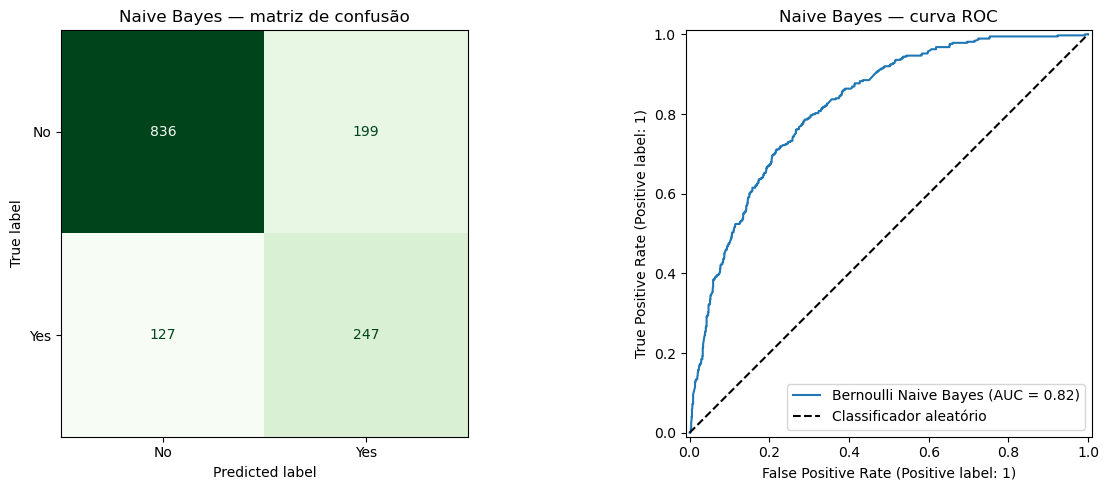

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_naive_bayes,
    display_labels=["No", "Yes"],
).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title("Naive Bayes — matriz de confusão")

RocCurveDisplay.from_predictions(
    y_test,
    probabilidade_churn_naive_bayes,
    name="Bernoulli Naive Bayes",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", label="Classificador aleatório")
axes[1].set_title("Naive Bayes — curva ROC")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Limitação das probabilidades

O módulo alerta que o Naive Bayes tende a produzir probabilidades extremas e mal calibradas quando as features não são realmente independentes. Por isso, `predict_proba` é usado aqui para ranking/ROC-AUC, mas seus valores não devem ser apresentados como risco absoluto de churn sem uma análise de calibração.

## 10. Comparação final dos modelos

O baseline, a Regressão Logística e o Bernoulli Naive Bayes são comparados no mesmo teste. ROC-AUC é a métrica principal; F1 e recall da classe churn mostram o efeito operacional no limiar `0,50`.

In [22]:
metricas_baseline = pd.Series(
    [baseline_majoritario, 0.0, 0.0, 0.0, 0.5],
    index=metricas_logistica.index,
    name="Baseline: sempre No",
)
comparacao_modelos = pd.DataFrame(
    {
        "Baseline: sempre No": metricas_baseline,
        "Regressão Logística": metricas_logistica["valor"],
        "Bernoulli Naive Bayes": metricas_naive_bayes["valor"],
    }
).T

display(comparacao_modelos.style.format("{:.3f}").highlight_max(axis=0))

melhor_modelo_auc = comparacao_modelos["ROC-AUC"].idxmax()
melhor_auc = comparacao_modelos.loc[melhor_modelo_auc, "ROC-AUC"]
print(f"Melhor modelo por ROC-AUC: {melhor_modelo_auc} ({melhor_auc:.3f})")

métrica,Acurácia,Precisão (Churn = 1),Recall (Churn = 1),F1 (Churn = 1),ROC-AUC
Baseline: sempre No,0.735,0.000,0.000,0.000,0.500
Regressão Logística,0.743,0.511,0.778,0.617,0.839
Bernoulli Naive Bayes,0.769,0.554,0.660,0.602,0.822


Melhor modelo por ROC-AUC: Regressão Logística (0.839)


In [23]:
tn_nb, fp_nb, fn_nb, tp_nb = matriz_confusao_naive_bayes.ravel()
print("Resumo — Bernoulli Naive Bayes (limiar 0,50)")
for nome_metrica, valor_metrica in metricas_naive_bayes["valor"].items():
    print(f"{nome_metrica}: {valor_metrica:.3f}")
print(f"Matriz de confusão: TN={tn_nb}, FP={fp_nb}, FN={fn_nb}, TP={tp_nb}")
print(f"Melhor alpha no CV: {busca_naive_bayes.best_params_['modelo__alpha']}")
print(f"ROC-AUC médio no CV: {busca_naive_bayes.best_score_:.3f}")

Resumo — Bernoulli Naive Bayes (limiar 0,50)
Acurácia: 0.769
Precisão (Churn = 1): 0.554
Recall (Churn = 1): 0.660
F1 (Churn = 1): 0.602
ROC-AUC: 0.822
Matriz de confusão: TN=836, FP=199, FN=127, TP=247
Melhor alpha no CV: 0.5
ROC-AUC médio no CV: 0.834


## Síntese final

**Melhor modelo:** Regressão Logística balanceada.

**Métrica escolhida e valor obtido:** ROC-AUC = **0,839**. No limiar 0,50, F1(Yes) = **0,617** e recall(Yes) = **0,778**.

**Principal decisão técnica e por quê:** todas as transformações aprendidas foram mantidas dentro de pipelines ajustados somente no treino. Para o Naive Bayes, as variáveis foram convertidas para indicadores binários e `alpha` foi escolhido por validação cruzada no treino, evitando usar o teste para selecionar o modelo.

**Se tivéssemos mais tempo:** testaríamos uma árvore ou ensemble para capturar a não linearidade de `MonthlyCharges` e a interação `Contract × InternetService`, além de escolher o limiar operacional por validação cruzada e avaliar a calibração das probabilidades.